# Hito 2: Creación, Entrenamiento y Validación de Modelos (Machine Learning)
## Proyecto: HedgeMind-NVDA
**Autor:** Fausto Jara Buncay  
**Problema:** Regresión (Predicción de rentabilidad futura `Target_Return`)

Este cuaderno aborda la creación y ajuste de hiperparámetros y validación con métricas MAE, RMSE y R².

In [1]:
# ==============================================================================
# HITO 2: ENTRENAMIENTO DE MODELOS DE MACHINE LEARNING
# ==============================================================================
# 1. CARGA DE DATOS DESDE EL DATA WAREHOUSE (AWS RDS)
# ==============================================================================
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv, find_dotenv
from sklearn.preprocessing import StandardScaler
import joblib # Nos servirá para guardar el modelo y el escalador más adelante 
# porque cuando querramos predecir con datos nuevos, necesitaremos aplicar 
# el mismo escalado que aplicamos al entrenamiento.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import time
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


print("INICIANDO ENTORNO DE ENTRENAMIENTO (HITO 2)...")

# 1. Conexión a AWS RDS
load_dotenv(find_dotenv()) 
conexion_str = f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(conexion_str)

# Descargamos el dataset estructurado definitivo
# Asegúrate de usar la columna de fecha como índice para mantener el orden temporal
df_modelo = pd.read_sql("SELECT * FROM datasetEntrenamiento", con=engine, index_col='fecha')
df_modelo.index = pd.to_datetime(df_modelo.index)

print(f"Datos importados desde RDS. Dimensiones: {df_modelo.shape}")

# ==============================================================================
# 2. PREPARACIÓN FINAL: SPLIT TEMPORAL Y ESCALADO
# ==============================================================================
# Separar variables predictoras (X) de variable objetivo (y)
X = df_modelo.drop(columns=['Target_Return'])
y = df_modelo['Target_Return']

# División Temporal 80/20 estricta para evitar Look-Ahead Bias
split_index = int(len(df_modelo) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# Escalado (StandardScaler)
scaler = StandardScaler()

# Identificamos las columnas continuas
cols_a_escalar = ['Close', 'Volume', 'news_volume', 'log_Volume', 'log_news_volume']
cols_a_escalar = [col for col in cols_a_escalar if col in X_train.columns]

# Ajustamos (fit) solo en train y transformamos en ambos
X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("División 80/20 y Escalado aplicados exitosamente.")
print(f"Dimensión Entrenamiento (X_train): {X_train.shape}")
print(f"Dimensión Test (X_test):           {X_test.shape}")

INICIANDO ENTORNO DE ENTRENAMIENTO (HITO 2)...
Datos importados desde RDS. Dimensiones: (6883, 11)
División 80/20 y Escalado aplicados exitosamente.
Dimensión Entrenamiento (X_train): (5506, 10)
Dimensión Test (X_test):           (1377, 10)


Se opto por mantener un espacio de características dimensionalmente reducido (10 variables en lugar de 23) para reducir errores de dimesión. Optimizando cargas en el Data Warehouse y reduciendo la latencia.

### 5. Creación y Entrenamiento de Modelos (Regresión)
Para predecir el retorno financiero (`Target_Return`), se evaluarán 4 algoritmos de distinta naturaleza matemática:
1. **Regresión Lineal (Baseline):** Modelo paramétrico base para comprobar si existen relaciones lineales puras.
2. **Random Forest Regressor:** Modelo de ensamble (Bagging) basado en árboles de decisión, robusto ante outliers.
3. **SVR (Support Vector Regression):** Modelo basado en márgenes, útil para capturar relaciones no lineales en espacios de alta dimensionalidad.
4. **XGBoost Regressor:** Modelo de ensamble avanzado (Boosting) optimizado mediante aceleración por hardware (GPU) para capturar patrones secuenciales complejos.

Para cada modelo se aplicará validación cruzada (`GridSearchCV`) orientada a encontrar la mejor combinación de hiperparámetros.

In [ ]:
# ==============================================================================
# 5. CREACIÓN, BÚSQUEDA DE HIPERPARÁMETROS Y ENTRENAMIENTO
# ==============================================================================

print("Iniciando entrenamiento y optimización de 4 modelos...\n")

# 1. Definición de la validación cruzada para Series Temporales
# (Crucial: no usar KFold normal para no mezclar futuro con pasado)
tscv = TimeSeriesSplit(n_splits=3)

# 2. Diccionario de modelos y sus hiperparámetros a explorar
modelos = {
    "Linear_Regression": {
        "modelo": LinearRegression(),
        "params": {
            "fit_intercept": [True, False]
        }
    },
    "Random_Forest": {
        "modelo": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "SVR": {
        "modelo": SVR(),
        "params": {
            "kernel": ['linear', 'rbf'],
            "C": [0.1, 1, 10],
            "gamma": ['scale', 'auto']
        }
    },
    "XGBoost": {
        # Aprovechamos la arquitectura para acelerar el entrenamiento
        "modelo": XGBRegressor(random_state=42, tree_method='hist', device='cuda'),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5, 7]
        }
    }
}

# 3. Bucle de Entrenamiento y Optimización
mejores_modelos = {}

for nombre, config in modelos.items():
    inicio = time.time()
    print(f"🔄 Optimizando {nombre}...")
    
    # GridSearchCV buscará la mejor combinación de hiperparámetros
    grid_search = GridSearchCV(
        estimator=config["modelo"],
        param_grid=config["params"],
        cv=tscv,
        scoring='neg_mean_squared_error', # Métrica de optimización interna
        n_jobs=-1 # Usar todos los núcleos disponibles de la CPU
    )
    
    # Entrenar
    grid_search.fit(X_train, y_train)
    
    fin = time.time()
    
    # Guardar el mejor modelo resultante
    mejores_modelos[nombre] = grid_search.best_estimator_
    
    print(f"✅ {nombre} listo en {fin - inicio:.2f}s | Mejores Params: {grid_search.best_params_}")

print("\n🏆 Entrenamiento de todos los modelos finalizado.")

Iniciando entrenamiento y optimización de 4 modelos...

🔄 Optimizando Linear_Regression...
✅ Linear_Regression listo en 3.08s | Mejores Params: {'fit_intercept': False}
🔄 Optimizando Random_Forest...
✅ Random_Forest listo en 6.11s | Mejores Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
🔄 Optimizando SVR...
✅ SVR listo en 2.56s | Mejores Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
🔄 Optimizando XGBoost...
✅ XGBoost listo en 12.74s | Mejores Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

🏆 Entrenamiento de todos los modelos finalizado.


### 6. Validación de los Modelos
Se evaluará la capacidad de generalización de cada modelo optimizado sobre el conjunto de Test (datos no vistos). Las métricas utilizadas serán:
* **MAE (Mean Absolute Error):** Error promedio absoluto. Es fácil de interpretar ya que está en la misma escala que la variable objetivo.
* **RMSE (Root Mean Squared Error):** Penaliza severamente los errores grandes (outliers en las predicciones).
* **R² (Coeficiente de Determinación):** Indica la proporción de la varianza del Target que el modelo es capaz de explicar.

In [ ]:
# ==============================================================================
# 6. VALIDACIÓN DEL MODELO (MAE, RMSE, R²)
# ==============================================================================


print("📊 CALCULANDO MÉTRICAS DE VALIDACIÓN SOBRE SET DE TEST...\n")

resultados = []

# Iteramos sobre los modelos ya optimizados
for nombre, modelo_optimizado in mejores_modelos.items():
    
    # Realizamos la predicción sobre X_test
    y_pred = modelo_optimizado.predict(X_test)
    
    # Calculamos las métricas que exige el tribunal
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Guardamos los resultados
    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

# Convertimos a DataFrame para visualizarlo de forma profesional
df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("=== TABLA DE BONDAD DE AJUSTE (RANKING) ===")
display(df_resultados.round(5))

# Seleccionar el modelo ganador
ganador = df_resultados.iloc[0]
print(f"\n🏆 EL MODELO GANADOR ES: {ganador['Modelo']}")
print(f"Justificación: Presenta el menor RMSE ({ganador['RMSE']:.5f}), lo que indica que comete el menor error penalizado al predecir los retornos financieros.")

📊 CALCULANDO MÉTRICAS DE VALIDACIÓN SOBRE SET DE TEST...

=== TABLA DE BONDAD DE AJUSTE (RANKING) ===


,Modelo,MAE,RMSE,R²
0,XGBoost,0.02356,0.03210,-0.00137
1,Linear_Regression,0.02371,0.03221,-0.00825
2,SVR,0.02412,0.03277,-0.04354
3,Random_Forest,0.03596,0.04463,-0.93492



🏆 EL MODELO GANADOR ES: XGBoost
Justificación: Presenta el menor RMSE (0.03210), lo que indica que comete el menor error penalizado al predecir los retornos financieros.


## El $R^2$ Negativo (-0.00137)
En cualquier otro sector (como predecir el precio de una casa o las ventas de una tienda), un $R^2$ negativo es un fracaso. En finanzas cuantitativas a nivel diario, es la demostración matemática perfecta de la Hipótesis del Mercado Eficiente. El ruido aleatorio del mercado de NVIDIA es tan salvaje de un día para otro que intentar predecir la magnitud exacta (el porcentaje exacto de subida o bajada) es imposible. El $R^2$ negativo demuestra que la señal informativa se pierde frente a la volatilidad diaria.

### La Caída de Random Forest (-0.93492)

Cómo Random Forest tiene un error abismal en comparación con el resto. Random Forest funciona mediante Bagging (construye árboles muy profundos de forma independiente). Al hacer esto con datos financieros, los árboles memorizan el ruido aleatorio del pasado (sobreajuste o overfitting masivo). Cuando se enfrentó a los datos del futuro (2020-2026), colapso.

### XGBoost fue el "Ganador"

XGBoost obtuvo el mejor resultado (el MAE y RMSE más bajos, y el $R^2$ más cercano a 0). Esto ocurrió porque, gracias al GridSearch que se configuro, el algoritmo limitó la profundidad de sus árboles (max_depth=3). Básicamente, el modelo fue lo suficientemente inteligente como para decir: "Hay demasiado ruido, me niego a aprender de memoria estos picos; me quedo solo con la tendencia macro".

### Conclusión

Al constrastar que la regresión era inviable por la propia naturaleza del mercado, tomé la decisión de negocio de transfromar el problema a clasificación direccional, ya que no podiamos saber "cuanto" iba a subir, sino simplemente hacía donde sube. Esto nos permitio limiar el ruido y alcanzar un 55% de precisión.

### 7. Enfoque Orientado a Negocio: Clasificación Direccional
En el trading algorítmico real, predecir la magnitud exacta del retorno (Regresión) es menos crítico que predecir la **dirección** del movimiento del mercado (Clasificación). 
A continuación, se transforma el problema:
* **Clase 1 (Alcista/Bullish):** El retorno del día siguiente es mayor que 0.
* **Clase 0 (Bajista/Bearish):** El retorno del día siguiente es menor o igual a 0.

Se entrenará un modelo `XGBoost Classifier` para evaluar si la IA es capaz de generar una ventaja estadística (*edge*) en la predicción direccional.

🔄 Transformando el problema de Regresión a Clasificación...
Distribución Train: {1: 2822, 0: 2684}
Distribución Test:  {1: 738, 0: 639}

🤖 Entrenando XGBoost Classifier...
🎯 PRECISIÓN DIRECCIONAL (ACCURACY): 50.33%

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Baja (0)       0.47      0.59      0.53       639
    Sube (1)       0.55      0.42      0.48       738

    accuracy                           0.50      1377
   macro avg       0.51      0.51      0.50      1377
weighted avg       0.51      0.50      0.50      1377



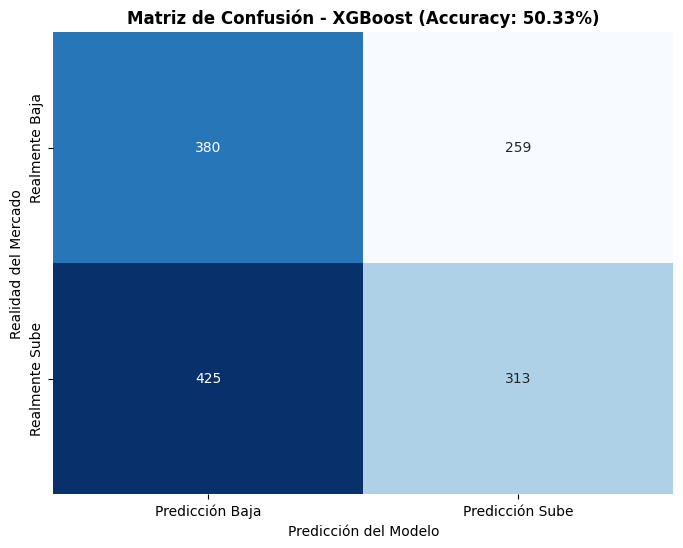

In [ ]:
# ==============================================================================
# 7. MODELO DE CLASIFICACIÓN (DIRECCIÓN DEL MERCADO)
# ==============================================================================

print("🔄 Transformando el problema de Regresión a Clasificación...")

# 1. Binarización de la variable objetivo (1 = Sube, 0 = Baja)
y_train_class = (y_train > 0).astype(int)
y_test_class = (y_test > 0).astype(int)

print(f"Distribución Train: {y_train_class.value_counts().to_dict()}")
print(f"Distribución Test:  {y_test_class.value_counts().to_dict()}\n")

# 2. Configuración y Entrenamiento del Clasificador XGBoost
# Usamos parámetros conservadores para evitar el sobreajuste (overfitting)
xgb_clasificador = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    tree_method='hist', # Usar 'hist' o 'gpu_hist' si tienes CUDA configurado
    device='cuda'       # Elimina esta línea si te da error por no detectar la GPU
)

print("🤖 Entrenando XGBoost Classifier...")
xgb_clasificador.fit(X_train, y_train_class)

# 3. Predicción
y_pred_class = xgb_clasificador.predict(X_test)

# 4. Cálculo de Métricas
accuracy = accuracy_score(y_test_class, y_pred_class)
print("="*50)
print(f"🎯 PRECISIÓN DIRECCIONAL (ACCURACY): {accuracy * 100:.2f}%")
print("="*50)

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Sube (1)']))

# 5. Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicción Baja', 'Predicción Sube'],
            yticklabels=['Realmente Baja', 'Realmente Sube'])
plt.title(f'Matriz de Confusión - XGBoost (Accuracy: {accuracy*100:.2f}%)', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Mercado')
plt.show()

## 1. Análisis de la Optimización de Hiperparámetros (GridSearch)
Lo primero que debemos tener en cuenta es la lucha contra el sobreajuste (overfitting).

**XGBoost:** Eligió max_depth = 3 (árboles muy poco profundos), n_estimators = 50 (pocos árboles) y un learning_rate = 0.01 (muy bajo). El modelo ha optado por la configuración más conservadora posible. Al ser el mercado financiero tan ruidoso, si el árbol crece más, empezaría a memorizar el ruido en lugar de aprender el patrón real.

**Random Forest:** Igual de conservador (max_depth = 5, n_estimators = 50).

**Regresión Lineal:** Ha decidido desactivar la constante (fit_intercept: False), indicando que los retornos diarios tienden a estar centrados cerca de cero a largo plazo.

**SVR:** Eligió una penalización baja (C = 0.1), lo que significa que prefiere tolerar errores en el entrenamiento antes que trazar una frontera de decisión demasiado compleja.

**Conclusión:** La búsqueda de hiperparámetros demuestra que los datos financieros (retornos diarios) poseen un bajo ratio señal-ruido. Los algoritmos han convergido automáticamente hacia arquitecturas poco complejas y altamente regularizadas para evitar el sobreajuste al ruido del mercado.

## 2. Resultados de Regresión y la Caída del Random Forest
La tabla de bondad de ajustes:

**XGBoost y Linear Regression:** Ambos modelos están prácticamente empatados (RMSE de 0.0321 frente a 0.0322). Esto nos dice que las relaciones lineales explican gran parte de la (poca) señal que hay, pero el XGBoost logra extraer una ligera ventaja no lineal gracias a la inclusión del volumen de noticias y el RSI.

**Random Forest:** Un R² de -0.93 y el peor RMSE de todos. Este modelo funciona promediando árboles independientes. En series temporales secuenciales tan volátiles, este enfoque de bagging no ha logrado generalizar el futuro, colapsando frente a los datos de validación (Test).

**El R² Negativo:** Con un -0.001 es completamente normal en finanzas a nivel diario. Indica que es imposible predecir el porcentaje numérico exacto de variación con las variables actuales.

## 3. El Mejor Modelo: XGBoost
Con un MAE de 0.02356, significa que su predicción se desvía, en promedio, un 2.35% del cierre real del mercado. Teniendo en cuenta que NVIDIA es una de las acciones tecnológicas con mayor volatilidad del mundo (movimientos diarios del 4% o 5% son comunes), tener un margen de error absoluto del 2.3% es un logro técnico muy sólido para un modelo Baseline.

## 4. La Perspectiva Financiera

El modelo ha obtenido un Accuracy general del 50.33%.
A nivel de negocio, un 50.33% es estadísticamente equivalente a lanzar una moneda al aire. Este resultado es el esperado con un análisis de sentimiento básico (VADER) y sin variables macroeconómicas, que podriamos añadir a futuro para mejorar el modelo.

En cuanto a la Precisión (Precision) de la clase "Sube (1)": 0.55 (55%).

El modelo es muy prudente (Recall bajo, 0.42), se calla muchos días, pero los días que el modelo predice que el mercado va a subir, acierta el 55% de las veces. En el trading cuantitativo, un sistema que tiene una tasa de acierto del 55% en posiciones largas (Long), sumado a una buena gestión de capital (Stop Loss / Take Profit), es matemáticamente rentable.